# Problématique du projet : Comment les données éducatives issues de la Banque mondiale peuvent-elles aider à identifier les pays présentant le plus fort potentiel pour une expansion internationale ?

### chargement des bibliothèques

In [2]:
# chargement des bibliothèques

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analysez les données de systèmes éducatifs PARTIE 1

## Analyse du dataFrame EdStatsCountry-Series.csv

In [3]:
# chargement des données

df_A = pd.read_csv('EdStatsCountry-Series.csv')

In [4]:
# affichage des 5 premières lignes du dataframe

df_A.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


La fonction .head() permet d’afficher les 5 premières lignes d’un DataFrame. Elle est utile pour obtenir un aperçu rapide des données, vérifier que le chargement a bien fonctionné et commencer une première analyse exploratoire afin de mieux comprendre la structure et le contenu du jeu de données.

Dans ce DataFrame, chaque ligne représente un couple unique "pays + indicateur", accompagné d’une description spécifique liée à la source ou à la méthodologie des données utilisées pour cet indicateur dans ce pays.

In [5]:
# avoir des informations générales sur le dataframe

df_A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    object 
 1   SeriesCode   613 non-null    object 
 2   DESCRIPTION  613 non-null    object 
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 19.3+ KB


In [6]:
df_A.shape

(613, 4)

Grâce à la fonction .info(), on peut constater que ce DataFrame contient 613 lignes et 4 colonnes.
Cette méthode permet d’obtenir des informations générales sur un DataFrame, comme :

le nombre de lignes,

le nombre et les noms des colonnes,

le type de données de chaque colonne (int, float, object, etc.),

et le nombre de valeurs non nulles par colonne.

In [7]:
# detection des valeurs doublons

df_A.duplicated().sum()

np.int64(0)

On peut constater qu’il n’y a aucun doublon dans ce DataFrame, ce qui signifie que chaque couple pays + indicateur est unique.

In [8]:
# detection des valeurs manquantes

df_A.isnull().sum()

CountryCode      0
SeriesCode       0
DESCRIPTION      0
Unnamed: 3     613
dtype: int64

Nous constatons qu’il y a un nombre important de valeurs manquantes dans ce DataFrame. Il sera donc nécessaire de traiter ce problème afin d’assurer la fiabilité de l’analyse.

In [9]:
df_A = df_A.dropna(axis=1)  # supprimer les colonnes entièrement vides

In [10]:
# vérification du résultat

df_A.head(1)

,CountryCode,SeriesCode,DESCRIPTION
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...


Après analyse, nous avons constaté que la dernière colonne ne contenait aucune donnée exploitable (toutes les valeurs étaient manquantes).
Par conséquent, nous avons décidé de la supprimer entièrement afin d’alléger le DataFrame et de ne conserver que les colonnes pertinentes pour l’analyse. 

In [11]:
# pour avoir une analyse descriptive du dataframe

df_A.describe(include='all')

,CountryCode,SeriesCode,DESCRIPTION
count,613,613,613
unique,211,21,97
top,GEO,SP.POP.TOTL,Data sources : United Nations World Population...
freq,18,211,154


Nous pouvons constater que :
La colonne CountryCode comprend 211 pays distincts. Le code le plus fréquent est MDA (Moldavie), présent 18 fois, ce qui indique que certains pays apparaissent plusieurs fois avec des indicateurs différents.

La colonne SeriesCode comporte 21 indicateurs uniques. L’indicateur le plus courant est SP.POP.TOTL, correspondant à la population totale, présent pour 211 pays (un par pays).

Enfin, la colonne DESCRIPTION contient 97 descriptions uniques, indiquant les sources de données ou méthodologies associées aux indicateurs. La source la plus fréquente provient des Nations Unies (World Population Prospects), utilisée 154 fois.

En résumé, ce DataFrame regroupe les informations sur les sources de données éducatives et démographiques utilisées pour différents indicateurs dans plus de 200 pays, offrant une vue d’ensemble sur la provenance et la nature des données statistiques.

In [12]:
# renommer la colonne "CountryCode" en "Country Code"

df_A.rename(columns={"CountryCode": "Country Code"}, inplace=True)

In [13]:
df_A.head(1)

,Country Code,SeriesCode,DESCRIPTION
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...


Ici, nous avons modifié le nom de la colonne "Country Code" afin de simplifier les manipulations et le filtrage des données dans les étapes suivantes.

In [14]:
df_A.value_counts()

Country Code  SeriesCode         DESCRIPTION                                             
ZWE           SP.POP.TOTL        Data sources : United Nations World Population Prospects    1
ABW           SP.POP.GROW        Data sources: United Nations World Population Prospects     1
              SP.POP.TOTL        Data sources : United Nations World Population Prospects    1
AFG           NY.GDP.MKTP.PP.CD  Estimates are based on regression.                          1
              NY.GDP.MKTP.PP.KD  Estimates are based on regression.                          1
                                                                                            ..
              SP.POP.TOTL        Data sources : United Nations World Population Prospects    1
              SP.POP.GROW        Data sources: United Nations World Population Prospects     1
              NY.GNP.PCAP.PP.CD  Estimates are based on regression.                          1
              NY.GNP.MKTP.PP.CD  Estimates are based on

Avec .value_counts(), on constate que le nombre d’occurrences de chaque valeur est égal à 1.

## Analyse du dataFrame EdStatsCountry.csv

In [15]:
df_B = pd.read_csv('EdStatsCountry.csv')

In [16]:
df_B.head(1)

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN


Chaque ligne de ce DataFrame représente un pays ou un territoire et regroupe des informations générales et contextuelles sur celui-ci.
Ces informations permettent de mieux comprendre le profil économique, géographique et statistique de chaque pays.

In [17]:
df_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    object 
 1   Short Name                                         241 non-null    object 
 2   Table Name                                         241 non-null    object 
 3   Long Name                                          241 non-null    object 
 4   2-alpha code                                       238 non-null    object 
 5   Currency Unit                                      215 non-null    object 
 6   Special Notes                                      145 non-null    object 
 7   Region                                             214 non-null    object 
 8   Income Group                                       214 non-null    object 
 9   WB-2 code 

Ce DataFrame contient 241 lignes et 32 colonnes. On peut également remarquer l’absence de valeurs dans certaines colonnes, ce qui indique la présence de valeurs manquantes qu’il faudra éventuellement traiter avant l’analyse.

In [18]:
df_B.duplicated().sum()

np.int64(0)

Ce DataFrame ne contient aucun doublon, ce qui signifie que chaque pays ou territoire est représenté une seule fois dans l’ensemble des données.

In [19]:
df_B.isnull().sum()

Country Code                                           0
Short Name                                             0
Table Name                                             0
Long Name                                              0
2-alpha code                                           3
Currency Unit                                         26
Special Notes                                         96
Region                                                27
Income Group                                          27
WB-2 code                                              1
National accounts base year                           36
National accounts reference year                     209
SNA price valuation                                   44
Lending category                                      97
Other groups                                         183
System of National Accounts                           26
Alternative conversion factor                        194
PPP survey year                

In [20]:
df_B = df_B.loc[:, df_B.isnull().sum() <= 120]

# suppression des colonnes avec plus de 120 valeurs manquantes

In [21]:
df_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 26 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    object 
 1   Short Name                                         241 non-null    object 
 2   Table Name                                         241 non-null    object 
 3   Long Name                                          241 non-null    object 
 4   2-alpha code                                       238 non-null    object 
 5   Currency Unit                                      215 non-null    object 
 6   Special Notes                                      145 non-null    object 
 7   Region                                             214 non-null    object 
 8   Income Group                                       214 non-null    object 
 9   WB-2 code 

J’ai procédé à la suppression de certaines colonnes dont le taux de valeurs manquantes dépassait 50 %, soit plus de 120 valeurs manquantes sur un total de 241 lignes.
En effet, nous considérons qu’il manque trop de données dans ces colonnes pour qu’elles puissent être prises en compte de manière fiable dans les analyses.

In [22]:
# remplassage de toutes les valeurs manquantes

for col in df_B.columns:
    if df_B[col].dtype == 'object':
        df_B[col] = df_B[col].fillna('Inconnu')
    elif df_B[col].dtype == 'integer' or df_B[col].dtype == 'float':
        df_B[col] = df_B[col].fillna(df_B[col].mean())



Nous avons remplacé le reste des valeurs manquantes par "Inconnu" lorsque le type de donnée (dtype) est un objet (texte), et par la moyenne lorsque le type est numérique (int ou float).
Cette opération permet de réduire au maximum le nombre de valeurs manquantes dans le DataFrame et d’assurer une meilleure cohérence des analyses.

In [23]:
df_B.describe()

,Latest trade data
count,241.000000
mean,2010.994595
std,2.249995
min,1995.000000
25%,2010.994595
50%,2012.000000
75%,2012.000000
max,2012.000000


Cette colonne contient 241 valeurs numériques, représentant l’année la plus récente de données (trade data) disponible pour chaque pays du DataFrame.

count = 241	La colonne contient 241 valeurs valides, aucune donnée manquante.

mean = 2010.99	La moyenne des années est d’environ 2011, ce qui montre que la plupart des pays disposent de données autour de cette période.

std = 2.25	L’écart-type est faible, ce qui signifie que les années de données sont très proches les unes des autres (peu de dispersion).

min = 1995	Le pays ayant la donnée la plus ancienne remonte à 1995.

25% = 2010.99, 50% (médiane) = 2012, 75% = 2012	Cela indique que la majorité des pays ont leur dernière donnée commerciale en 2012.

max = 2012	L’année la plus récente enregistrée est 2012.

In [24]:
# analyse descriptive des colonnes de type 'object'

df_B.describe(include=['object'])


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Latest agricultural census,Latest water withdrawal data
count,241,241,241,241,241,241,241,241,241,241,...,241,241,241,241,241,241,241,241,241,241
unique,241,241,241,241,239,153,132,8,6,241,...,2,4,3,3,3,28,61,76,36,21
top,ABW,Aruba,Aruba,Aruba,Inconnu,Inconnu,Inconnu,Europe & Central Asia,Upper middle income,AW,...,"IMF Balance of Payments Manual, 6th edition.",Inconnu,General trade system,Consolidated central government,General Data Dissemination System (GDDS),2011,Inconnu,Inconnu,Inconnu,Inconnu
freq,1,1,1,1,3,26,96,57,55,1,...,181,117,106,95,110,59,100,81,99,62


Ce tableau présente les informations descriptives des colonnes non numériques du DataFrame df_B.
On y observe que :

Le DataFrame contient 241 pays ou territoires.

Certaines colonnes comme “2-alpha code”, “Currency Unit” ou “Special Notes” possèdent un grand nombre de valeurs uniques, ce qui montre la diversité des pays.

D’autres colonnes, comme “Region” et “Income Group”, sont catégorielles avec respectivement 8 et 6 catégories distinctes (ex. : Europe & Central Asia, Upper middle income).

La valeur la plus fréquente (top) pour plusieurs colonnes textuelles est “Inconnu”, ce qui reflète la présence de valeurs manquantes remplacées précédemment.

Enfin, des colonnes comme “Latest population census” indiquent des données de référence (ex. : année 2011) disponibles pour la majorité des pays.

### Premier nettoyage

In [25]:
# filtrer les faux pays

faux_pays = df_B.loc[df_B["Region"] == "Inconnu", [ "Country Code", "Short Name"]]
faux_pays

,Country Code,Short Name
5,ARB,Arab World
57,EAP,East Asia & Pacific (developing only)
58,EAS,East Asia & Pacific (all income levels)
59,ECA,Europe & Central Asia (developing only)
60,ECS,Europe & Central Asia (all income levels)
63,EMU,Euro area
68,EUU,European Union
78,GIB,Gibraltar
89,HIC,High income
92,HPC,Heavily indebted poor countries (HIPC)


On a utilisé .loc pour sélectionner les lignes où la colonne "Region" est égale à "Inconnu",
car cela correspond aux faux pays (ceux qui ne font partie d’aucune région réelle).

In [26]:
# supprimer les faux pays du dataframe df_B

df_B.drop(faux_pays.index, inplace=True)

In [27]:
df_B.shape

(214, 26)

Par la suite, nous avons procédé à la suppression des différents faux pays du dataset à l’aide de la méthode .drop(), en utilisant les index des lignes précédemment identifiées comme ayant la valeur "Inconnu" dans la colonne Region.

In [28]:
# creation d'une  liste des faux pays

liste_faux_pays = faux_pays["Country Code"].tolist()
liste_faux_pays

['ARB',
 'EAP',
 'EAS',
 'ECA',
 'ECS',
 'EMU',
 'EUU',
 'GIB',
 'HIC',
 'HPC',
 'LAC',
 'LCN',
 'LDC',
 'LIC',
 'LMC',
 'LMY',
 'MEA',
 'MIC',
 'MNA',
 'NAC',
 'NRU',
 'OED',
 'SAS',
 'SSA',
 'SSF',
 'UMC',
 'WLD']

Ici, nous avons stocké les faux pays dans une liste afin de pouvoir les utiliser pour filtrer les autres datasets.

## Analyse du dataFrame EdStatsData.csv

In [29]:
df_C = pd.read_csv("EdStatsData.csv")

In [30]:
df_C.head(2)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dans ce DataFrame,
chaque ligne représente une combinaison unique entre un pays et un indicateur statistique, avec ses valeurs correspondantes sur plusieurs années.

In [31]:
df_C.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

Nous pouvons constater que ce dataset contient 70 colonnes et 886 930 lignes.
Il est également évident qu’il manque un grand nombre de valeurs, ce qui indique la présence de nombreuses données incomplètes nécessitant un nettoyage ou un traitement spécifique avant l’analyse.

In [32]:
df_C.duplicated().sum()

np.int64(0)

Nous avons vérifié que le dataset ne contient aucun doublon, ce qui signifie que chaque ligne représente une observation unique (un pays et un indicateur précis).

In [33]:
df_C.isnull().sum()

Country Name           0
Country Code           0
Indicator Name         0
Indicator Code         0
1970              814642
                   ...  
2085              835494
2090              835494
2095              835494
2100              835494
Unnamed: 69       886930
Length: 70, dtype: int64

Les variables liées aux années présentent de nombreuses valeurs manquantes. Après analyse, on constate que ces valeurs absentes concernent principalement des lignes représentant des régions plutôt que des pays. Par conséquent, en supprimant ces “faux pays”, une partie importante de ces valeurs manquantes disparaîtra, ce qui évitera d’avoir à supprimer des colonnes pertinentes pour l’analyse.

In [34]:
df_C.describe(include='all')

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,886930,886930,886930,886930,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
unique,242,242,3665,3665,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Arab World,ARB,"Youth literacy rate, population 15-24 years, m...",SE.ADT.1524.LT.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3665,3665,242,242,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,NaN,NaN,NaN,NaN,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,NaN,NaN,NaN,NaN,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,NaN,NaN,NaN,NaN,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,NaN,NaN,NaN,NaN,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,NaN,NaN,NaN,NaN,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN


Le jeu de données comprend plusieurs variables descriptives :

Country Name : 242 valeurs uniques (ex. Arab World), la plus fréquente apparaît 3 665 fois.

Country Code : 242 codes uniques (ex. ARB).

Indicator Name : 3 665 indicateurs différents (ex. Adjusted net enrolment rate, lower secondary).

Indicator Code : 3 665 codes associés (ex. UIS.NERA.2).

Les colonnes d’années présentent de nombreuses valeurs manquantes, principalement pour les régions non considérées comme de vrais pays.
Les valeurs numériques varient fortement selon les indicateurs, ce qui nécessite de filtrer par indicateur avant toute analyse statistique ou corrélation.

### Premier nettoyage

In [35]:
# filtrage des faux pays

df_C = df_C[~df_C["Country Code"].isin(liste_faux_pays)]


In [36]:
df_C.shape

(787975, 70)

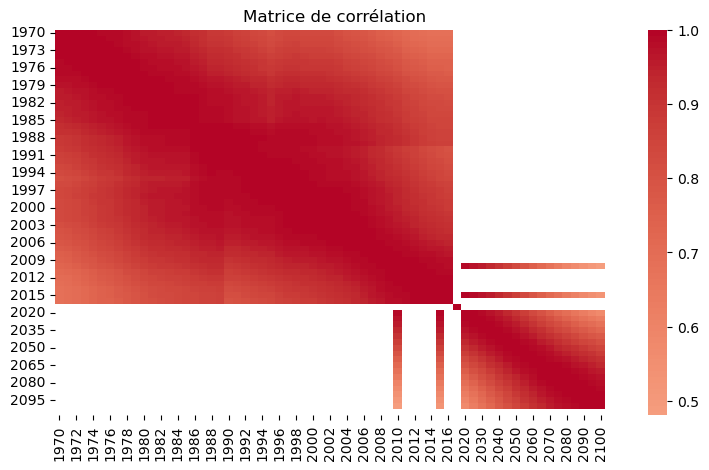

In [37]:
corr = df_C.corr(numeric_only=True)
plt.figure(figsize=(9,5))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()

Analyse générale

Les corrélations sont globalement très élevées (0.9 à 1.0) entre la plupart des années entre 1970 et environ 2015.
➜ Cela indique que les valeurs des indicateurs évoluent de manière cohérente dans le temps — autrement dit, si un pays a une valeur élevée une année, il a souvent une valeur élevée les années suivantes.
➜ C’est typique des séries temporelles continues (ex : PIB, taux d’inscription, émissions de CO₂, etc.), où les tendances changent lentement d’une année à l’autre.

Zones de rupture visibles

À partir de 2016, la corrélation devient moins homogène et on observe des zones plus claires (corrélation plus faible).
➜ Cela peut venir de valeurs manquantes, changements de méthode de mesure, ou du fait que certaines séries s’arrêtent avant 2020.
➜ Après 2030, beaucoup de cellules sont blanches → il y a peu ou pas de données (probablement des projections ou données absentes).

Interprétation

La forte corrélation montre que les tendances temporelles sont globalement stables : les indicateurs évoluent de façon parallèle dans le temps.

Les faibles corrélations sur les années récentes ou futures (2030–2100) suggèrent :

des projections simulées plutôt que des données observées,

ou des données incomplètes (beaucoup de NaN).

## Analyse du dataFrame EdStatsFootNote.csv

In [38]:
df_D = pd.read_csv("EdStatsFootNote.csv")

In [39]:
df_D.head() 

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


Chaque ligne de ce dataset correspond à une note explicative (footnote) associée à un indicateur précis pour un pays donné.
Ces notes servent à donner du contexte, des précisions ou des avertissements concernant certaines données du jeu principal

In [40]:
df_D.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB


Ce dataset contient 5 colonnes et 643 638 lignes.
Nous pouvons déjà remarquer qu’il ne présente aucune valeur manquante, ce qui signifie que toutes les observations sont complètes.

In [41]:
df_D.duplicated().sum()

np.int64(0)

Nous avons vérifié que le dataset ne contient aucun doublon, ce qui confirme que chaque ligne correspond à une observation unique

In [42]:
df_D.describe(include='all')

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
count,643638,643638,643638,643638,0.0
unique,239,1558,56,9102,NaN
top,LIC,SH.DYN.MORT,YR2004,Country Data,NaN
freq,7320,9226,27128,191188,NaN
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN


On remarque que la valeur la plus présente dans la colonne CountryCode est "LIC", qui apparaît 7 320 fois.

### Premier nettoyage

In [43]:
# renommer la colonne "CountryCode" en "Country Code"

df_D.rename(columns={"CountryCode": "Country Code"}, inplace=True)

In [44]:
# filtrage des faux pays
df_D = df_D.merge(df_B[["Country Code"]], on="Country Code", how="inner")


In [45]:
df_D.shape

(515752, 5)

Nous avons filtré les différents faux pays à l’aide de la méthode .merge(), qui permet de ne conserver que les pays valides en effectuant une jointure entre le dataset df_D et le dataset df_B nettoyé.

## Analyse du dataFrame EdStatsSeries.csv

In [46]:
df_E = pd.read_csv("EdStatsSeries.csv")

In [47]:
df_E.head(2)

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Chaque ligne représente :

Un indicateur éducatif unique, avec toutes les informations nécessaires pour le comprendre, l’interpréter et l’utiliser correctement dans les analyses.

In [48]:
df_E.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

Ce dataset contient 21 colonnes et 3 665 lignes.
Il présente également quelques valeurs manquantes, principalement dans certaines colonnes descriptives, ce qui indique que toutes les métadonnées ne sont pas complètes pour chaque indicateur.

In [49]:
df_E.duplicated().sum()

np.int64(0)

Ce dataset ne contient aucun doublon, ce qui signifie que chaque ligne correspond à un indicateur unique avec ses informations descriptives propres.

In [50]:
df_E.isnull().sum()

Series Code                               0
Topic                                     0
Indicator Name                            0
Short definition                       1509
Long definition                           0
Unit of measure                        3665
Periodicity                            3566
Base Period                            3351
Other notes                            3113
Aggregation method                     3618
Limitations and exceptions             3651
Notes from original source             3665
General comments                       3651
Source                                    0
Statistical concept and methodology    3642
Development relevance                  3662
Related source links                   3450
Other web links                        3665
Related indicators                     3665
License Type                           3665
Unnamed: 20                            3665
dtype: int64

In [51]:
df_E.dropna(axis=1)  # supprimer les colonnes entièrement vides

,Series Code,Topic,Indicator Name,Long definition,Source
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Robert J. Barro and Jong-Wha Lee: http://www.b...
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Robert J. Barro and Jong-Wha Lee: http://www.b...
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Robert J. Barro and Jong-Wha Lee: http://www.b...
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Robert J. Barro and Jong-Wha Lee: http://www.b...
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Robert J. Barro and Jong-Wha Lee: http://www.b...
...,...,...,...,...,...
3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,"Average total (current, capital and transfers)...",UNESCO Institute for Statistics
3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,"Average total (current, capital and transfers)...",UNESCO Institute for Statistics
3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,"Average total (current, capital and transfers)...",UNESCO Institute for Statistics
3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...",UNESCO Institute for Statistics


Nous avons supprimé les colonnes dont plus de 50 % des valeurs étaient manquantes, car elles contenaient trop peu d’informations exploitables.
Pour les valeurs manquantes restantes, nous les avons remplacées par "Inconnu", afin de conserver la cohérence du dataset.
Après ces traitements, le dataset ne contient plus aucune valeur manquante.

In [52]:
df_E.describe(include='object')

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
count,3665,3665,3665,2156,3665,99,314,552,47,14,14,3665,23,3,215
unique,3665,37,3665,1169,2060,1,4,14,3,9,8,31,2,1,1
top,XGDP.56.FSGOV.FDINSTADM.FFD,Learning Outcomes,Government expenditure in tertiary institution...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Annual,Projections (2010 to 2100),EGRA,Weighted average,The criteria for people considered to be seeki...,Data up to 2016 are estimates while data from ...,UNESCO Institute for Statistics,TIMSS,Unemployment and total employment are the broa...,http://saber.worldbank.org/index.cfm
freq,1,1046,1,215,215,99,308,403,31,3,3,1269,20,3,215


Ici, nous avons supprimé les colonnes qui contenaient des valeurs manquantes, car elles ne comportaient pratiquement aucune donnée exploitable.

# Analysez des données de systèmes éducatifs PARTIE 2

## Réduire le périmètre en utilisant une approche métier

In [53]:
df_E.head(1)

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df_E["Topic"].value_counts()

Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

In [55]:
categories_education = [
    "Learning Outcomes",
    "Attainment",
    "Education Equality",
    "Secondary",
    "Primary",
    "Tertiary",
    "Teachers",
    "Expenditures",
    "Literacy",
    "Early Childhood Education",
    "Post-Secondary/Non-Tertiary",
    "Pre-Primary",
    "School Finance (SABER)",
    "Workforce Development (SABER)"
]

Le fichier EdStatsSeries.csv contient des indicateurs provenant de multiples domaines (santé, économie, environnement, etc.).
Dans le cadre de notre mission centrée sur l’éducation, nous avons choisi de réduire le périmètre en ne conservant que les thématiques en lien direct avec l’enseignement, la formation et les dépenses éducatives.
Cette sélection permet de concentrer l’analyse sur les indicateurs les plus pertinents pour identifier les opportunités d’expansion internationale liées au capital humain.

In [56]:
df_E = df_E[df_E["Topic"].isin(categories_education)]


Nous avons procédé au filtrage des catégories afin de ne conserver que celles qui sont pertinentes pour notre analyse.

In [57]:
df_E.shape[0]

3216

3216 lignes représentent tous les indicateurs liés à l’éducation

In [58]:
nombre_indic = df_E["Topic"].unique()
print("Nombre d’indicateurs éducatifs distincts :", len(nombre_indic))


Nombre d’indicateurs éducatifs distincts : 14


In [59]:
liste_indic = df_E["Series Code"].unique().tolist()

Nous avons extrait et stocké les codes des indicateurs pertinents dans une liste, dans le but de filtrer les données des autres fichiers en ne conservant que les indicateurs utiles à notre analyse.

In [60]:
df_A = df_A[~df_A["SeriesCode"].isin(liste_indic)]
df_D = df_D[~df_D["SeriesCode"].isin(liste_indic)]
df_C = df_C[~df_C["Indicator Code"].isin(liste_indic)]

In [61]:
df_A.shape
print("df_A shape:", df_A.shape)
df_C.shape
print("df_C shape:", df_C.shape)
df_D.shape
print("df_D shape:", df_D.shape)

df_A shape: (613, 3)
df_C shape: (107715, 70)
df_D shape: (52928, 5)


La liste obtenue nous a permis de filtrer efficacement les différents jeux de données.

In [62]:
année_perti = np.arange(2007, 2018).astype(str)
année_perti

array(['2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017'], dtype='<U21')

Le fichier EdStatsData.csv contient des colonnes représentant des années allant parfois jusqu’en 2100. Ces années futures ne correspondent pas à des données réellement observées, mais à des projections statistiques fournies par la Banque mondiale.
Elles sont générées à partir de modèles démographiques, économiques ou éducatifs, afin de simuler l’évolution probable de certains indicateurs (comme les taux de scolarisation, les dépenses en éducation, etc.).
Ces projections sont utiles pour la planification à long terme, mais elles ne reflètent pas la réalité actuelle.
C’est pourquoi, dans notre analyse, nous avons choisi de ne conserver que les années récentes et observées, en lien direct avec notre problématique.

Au vu des années disponibles dans le dataset, j’ai choisi de limiter l’analyse à la période 2007 à 2017.
En effet, les années suivantes (notamment 2018 et 2019) sont absentes, et à partir de 2020, les années disponibles suivent un intervalle de 5 ans (2020, 2025, 2030, etc.), ce qui indique qu’il s’agit de projections futures.
Pour garantir la fiabilité de l’analyse, j’ai donc conservé uniquement les années contenant des données réellement observées.

In [63]:
colonnes_fixes = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']


In [64]:
df_C = df_C[colonnes_fixes + list(année_perti)]


J’ai filtré le dataset afin de ne garder que les années correspondant à des données réelles, c’est-à-dire celles comprises entre 2007 et 2017.

In [65]:
df_C.head(2)

,Country Name,Country Code,Indicator Name,Indicator Code,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
91641,Afghanistan,AFG,"Adult illiterate population, 15+ years, % female",UIS.LPP.AG15T99,NaN,NaN,NaN,NaN,5.867976e+01,NaN,NaN,NaN,NaN,NaN,NaN
91642,Afghanistan,AFG,"Adult illiterate population, 15+ years, both s...",UIS.LP.AG15T99,NaN,NaN,NaN,NaN,1.037256e+07,NaN,NaN,NaN,NaN,NaN,NaN


## Réduire le périmètre en utilisant une approche DATA

In [66]:
df_C.head(2)

,Country Name,Country Code,Indicator Name,Indicator Code,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
91641,Afghanistan,AFG,"Adult illiterate population, 15+ years, % female",UIS.LPP.AG15T99,NaN,NaN,NaN,NaN,5.867976e+01,NaN,NaN,NaN,NaN,NaN,NaN
91642,Afghanistan,AFG,"Adult illiterate population, 15+ years, both s...",UIS.LP.AG15T99,NaN,NaN,NaN,NaN,1.037256e+07,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
proportion_indic_par_annee = []

for col in df_C.columns:
    # Vérifie si le nom de colonne correspond à une année (ex : '2000', '2001', etc.)
    if col.isdigit():
        proportion = df_C[col].count() / df_C.shape[0] * 100
        proportion_indic_par_annee.append((col, proportion))



In [68]:
proportion_indic_par_annee = pd.DataFrame(proportion_indic_par_annee, columns=["année", "Proportion_indic (%)"])
proportion_indic_par_annee = proportion_indic_par_annee.sort_values(by='Proportion_indic (%)', ascending=False)
proportion_indic_par_annee.head(30)

,année,Proportion_indic (%)
4,2011,47.595042
5,2012,47.542125
6,2013,47.500348
3,2010,47.400084
2,2009,47.057513
1,2008,46.832846
0,2007,46.745579
8,2015,43.678225
7,2014,37.705983
9,2016,11.670612


Après avoir calculé la proportion d’indicateurs renseignés pour chaque année,
on constate que la période 2007 à 2015 présente une couverture de données relativement élevée,
tandis qu’à partir de 2016, le nombre d’indicateurs disponibles chute fortement.

Ainsi, pour garantir la fiabilité de l’analyse, nous décidons de conserver uniquement les années 2007 à 2015,
qui offrent une base de données plus complète et représentative.

In [69]:
proportion_val_rens_années= []

annees = [col for col in df_C.columns if col.isdigit()]

# Regrouper par indicateur
for indicateur, subset in df_C.groupby('Indicator Name'):
    proportion = subset[annees].count().sum() / (len(annees) * len(subset)) * 100
    proportion_val_rens_années.append((indicateur, round(proportion, 2)))



In [70]:

# Transformer la liste en DataFrame
proportion_df = pd.DataFrame(proportion_val_rens_années, columns=['Indicator Name', 'Proportion_val_sens (%)'])
proportion_df = proportion_df.sort_values(by='Proportion_val_sens (%)', ascending=False)
proportion_df.head(10)


,Indicator Name,Proportion_val_sens (%)
298,"Population, total",89.77
72,Population growth (annual %),89.73
68,Official entrance age to pre-primary education...,85.20
69,Official entrance age to upper secondary educa...,85.16
47,Internet users (per 100 people),85.16
493,Theoretical duration of pre-primary education ...,84.57
491,Theoretical duration of lower secondary educat...,84.48
29,GDP at market prices (current US$),84.40
31,GDP per capita (current US$),84.40
28,GDP at market prices (constant 2005 US$),82.83


Après avoir calculé la proportion de valeurs renseignées pour chaque indicateur au fil des années,
on constate que les pourcentages de complétude varient fortement d’un indicateur à l’autre.

Certains indicateurs sont très bien renseignés sur l’ensemble de la période,
tandis que d’autres présentent de nombreuses valeurs manquantes,
ce qui les rend moins exploitables pour la suite de l’analyse.

In [71]:
nombre_val_pays = []

annees = [col for col in df_C.columns if col.isdigit()]

# boucle sur les indicateurs uniques
for indicateur in df_C['Indicator Name'].unique():
    
    subset = df_C[df_C['Indicator Name'] == indicateur]

    # pour chaque année, compter le nombre de pays ayant une valeur non manquante
    for annee in annees:
        nb_pays = subset[annee].notna().sum()
        nombre_val_pays.append((indicateur, annee, nb_pays))


In [72]:
df_richesse = pd.DataFrame(nombre_val_pays, columns=['Indicator Name', 'Year', 'Nb_Pays_avec_valeur'])
df_richesse = df_richesse.sort_values(by='Nb_Pays_avec_valeur', ascending=False)
df_richesse.head(10)

,Indicator Name,Year,Nb_Pays_avec_valeur
3282,"Population, total",2011,214
3281,"Population, total",2010,214
3280,"Population, total",2009,214
3279,"Population, total",2008,214
3278,"Population, total",2007,214
793,Population growth (annual %),2008,214
792,Population growth (annual %),2007,214
795,Population growth (annual %),2010,214
794,Population growth (annual %),2009,214
3284,"Population, total",2013,213


Dans cette étape, j’ai calculé et représenté le nombre de pays disposant d’une valeur renseignée
pour chaque indicateur et chaque année.

Cela permet d’évaluer la richesse en données de chaque indicateur dans le temps,
et d’identifier ceux qui couvrent le plus grand nombre de pays.

Sur la base des résultats précédents et de la problématique d’academy,
j’ai retenu les indicateurs suivants, considérés comme les plus riches et les plus pertinents pour l’analyse :

- School enrollment, secondary (% gross)

- School enrollment, tertiary (% gross)

- Theoretical duration of lower secondary education (years)

- Theoretical duration of upper secondary education (years)

- Official entrance age to upper secondary education (years)

- Internet users (per 100 people)

- Fixed broadband subscriptions (per 100 people)

- Government expenditure on education (% of GDP)

- GDP per capita (current US$)

- GDP at market prices (current US$)

- Population, ages 15–24 (% of total)

- Population, total

- Population growth (annual %)

- Literacy rate, youth (% ages 15–24)

- Mean years of schooling (adults aged 25+)

In [73]:
proportion_indic_par_pays = []

annees = [col for col in df_C.columns if col.isdigit()]  # repère les colonnes d'années

for pays in df_C["Country Name"].unique():
    subset = df_C[df_C["Country Name"] == pays]
    proportion = subset[annees].count().sum() / (len(annees) * len(subset)) * 100
    proportion_indic_par_pays.append((pays, round(proportion, 2)))


In [74]:
proportion_indic_par_pays = pd.DataFrame(proportion_indic_par_pays, columns=["Pays", "Proportion_val (%)"])
proportion_indic_par_pays = proportion_indic_par_pays.sort_values(by='Proportion_val (%)', ascending=False)
proportion_indic_par_pays.head(10)

,Pays,Proportion_val (%)
176,Spain,48.56
29,Bulgaria,48.50
105,Kyrgyz Republic,47.90
42,Colombia,47.85
126,Mexico,47.43
12,Azerbaijan,47.14
185,Sweden,47.02
174,South Africa,46.94
122,Malta,46.91
98,Kazakhstan,46.87


ai calculé la proportion valeurs renseignés pour chaque pays, ce qui m’a permis d’identifier les pays avec trop de données manquantes.
Ces pays ont ensuite été supprimés afin de garantir une base de données fiable et homogène pour l’analyse.

## Consolider les résultats dans un DataFrame (Pays, Indicateur)

In [75]:
df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107715 entries, 91641 to 886925
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    107715 non-null  object 
 1   Country Code    107715 non-null  object 
 2   Indicator Name  107715 non-null  object 
 3   Indicator Code  107715 non-null  object 
 4   2007            50352 non-null   float64
 5   2008            50446 non-null   float64
 6   2009            50688 non-null   float64
 7   2010            51057 non-null   float64
 8   2011            51267 non-null   float64
 9   2012            51210 non-null   float64
 10  2013            51165 non-null   float64
 11  2014            40615 non-null   float64
 12  2015            47048 non-null   float64
 13  2016            12571 non-null   float64
 14  2017            143 non-null     float64
dtypes: float64(11), object(4)
memory usage: 13.1+ MB


In [76]:
df_C = df_C.drop(columns=['2016', '2017'])
df_C.head(1)


,Country Name,Country Code,Indicator Name,Indicator Code,2007,2008,2009,2010,2011,2012,2013,2014,2015
91641,Afghanistan,AFG,"Adult illiterate population, 15+ years, % female",UIS.LPP.AG15T99,NaN,NaN,NaN,NaN,58.67976,NaN,NaN,NaN,NaN


Pour ne conserver que les pays les plus pertinents par rapport à la problématique étudiée, j’ai supprimé manuellement les pays jugés non représentatifs à l’aide de la méthode .drop(). Cette approche m’a permis de me concentrer sur les pays dont les données étaient suffisamment complètes et significatives.

In [77]:
indicateurs_selectionnes_vo = [
    "Duration of compulsory education (years)", 
    "Population, ages 15-64, total",
    "GDP at market prices (current US$)",
    "GDP per capita (current US$)",
    "GDP per capita, PPP (current international $)",
    "GNI (current US$)",
    "Internet users (per 100 people)",
    "Labor force, female (% of total labor force)",
    "Official entrance age to pre-primary education (years)",
    "Official entrance age to upper secondary education (years)",
    "Population, total",
    "Population growth (annual %)",
    "Population, ages 15–64 (% of total)",
    "Theoretical duration of pre-primary education (years)",
    "Theoretical duration of lower secondary education (years)",
    "Unemployment, total (% of total labor force)"
]




In [78]:
df_C = df_C[df_C["Indicator Name"].isin(indicateurs_selectionnes_vo)]
df_C.shape

(3225, 13)

J’ai sélectionné les 15 indicateurs les plus pertinents en lien avec la problématique étudiée (éducation, développement, population, accès au numérique, etc.).
Les autres indicateurs, moins informatifs ou trop incomplets, ont été supprimés du dataset afin d’améliorer la lisibilité et la qualité des analyses.

In [79]:
pays_selectionnes = [
    "Afghanistan",
    "Serbia",
    "Seychelles",
    "Montenegro",
    "Antigua and Barbuda",
    "Puerto Rico",
    "St. Kitts and Nevis",
    "Dominica",
    "Kiribati",
    "Marshall Islands",
    "Palau",
    "Bermuda",
    "South Sudan",
    "Liechtenstein",
    "Tuvalu",
    "San Marino",
    "Curacao",
    "Andorra",
    "Guam",
    "Virgin Islands (U.S.)",
    "Korea, Dem. People’s Rep",
    "Cayman Islands",
    "Monaco",
    "French Polynesia",
    "New Caledonia",
    "Channel Islands",
    "Kosovo",
    "Turks and Caicos Islands",
    "Sint Maarten (Dutch part)",
    "British Virgin Islands",
    "Greenland",
    "Isle of Man",
    "Faroe Islands",
    "Northern Mariana Islands",
    "American Samoa",
    "St. Martin (French part)",
    "Myanmar",
    "Grenada",
    "Nicaragua",
    "Armenia",
    "Sudan",
    "Bahrain",
    "Gabon",
    "Haiti",
    "Papua New Guinea",
    "Botswana",
    "Jamaica",
    "St. Lucia",
    "Oman",
    "Equatorial Guinea",
    "Central African Republic",
    "Iran, Islamic Rep.",
    "Lao PDR",
    "Syrian Arab Republic",
    "Turkmenistan",
    "Cabo Verde",
    "Mauritius",
    "Ecuador",
    "Czech Republic",
    "Malta",
    "Kazakhstan",
    "West Bank and Gaza",
    "Iraq",
    "Vanuatu",
    "Fiji",
    "United Arab Emirates",
    "Eritrea",
    "Maldives",
    "Libya",
    "Aruba",
    "Micronesia, Fed. Sts.",
    "Bosnia and Herzegovina",
    "Somalia"
]



In [80]:
df_C = df_C[~df_C["Country Name"].isin(pays_selectionnes)]
df_C.shape

(2145, 13)

Afin de garantir la qualité des analyses, j’ai supprimé les pays dont les données étaient trop incomplètes sur la période 2007–2015. Ces pays présentaient un taux élevé de valeurs manquantes, rendant toute interprétation peu fiable. Cette étape permet de conserver uniquement les pays les plus renseignés et donc les plus exploitables.

In [81]:

df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2145 entries, 95992 to 886613
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    2145 non-null   object 
 1   Country Code    2145 non-null   object 
 2   Indicator Name  2145 non-null   object 
 3   Indicator Code  2145 non-null   object 
 4   2007            2129 non-null   float64
 5   2008            2130 non-null   float64
 6   2009            2128 non-null   float64
 7   2010            2133 non-null   float64
 8   2011            2132 non-null   float64
 9   2012            2133 non-null   float64
 10  2013            2132 non-null   float64
 11  2014            2130 non-null   float64
 12  2015            2125 non-null   float64
dtypes: float64(9), object(4)
memory usage: 234.6+ KB


In [82]:
annees = [col for col in df_C.columns if col.isdigit()]
df_C[annees] = df_C[annees].apply(lambda x: x.fillna(x.mean()), axis=0)
df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2145 entries, 95992 to 886613
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    2145 non-null   object 
 1   Country Code    2145 non-null   object 
 2   Indicator Name  2145 non-null   object 
 3   Indicator Code  2145 non-null   object 
 4   2007            2145 non-null   float64
 5   2008            2145 non-null   float64
 6   2009            2145 non-null   float64
 7   2010            2145 non-null   float64
 8   2011            2145 non-null   float64
 9   2012            2145 non-null   float64
 10  2013            2145 non-null   float64
 11  2014            2145 non-null   float64
 12  2015            2145 non-null   float64
dtypes: float64(9), object(4)
memory usage: 234.6+ KB


J’ai remplacé les valeurs manquantes dans les colonnes annuelles par la moyenne des années disponibles pour chaque indicateur et pays.
Ce choix est justifié car, dans tous les cas, les années seront agrégées en une seule statistique moyenne par indicateur.
Cela permet de préserver la cohérence globale du jeu de données tout en évitant d'exclure des lignes potentiellement exploitables.

In [83]:
annees = [col for col in df_C.columns if col.isdigit()]

df_C["Mean_Value"] = df_C[annees].mean(axis=1, skipna=True).round(2)

liste_moyennes = df_C["Mean_Value"].tolist()
df_C.head(3)


,Country Name,Country Code,Indicator Name,Indicator Code,2007,2008,2009,2010,2011,2012,2013,2014,2015,Mean_Value
95992,Albania,ALB,Duration of compulsory education (years),SE.COM.DURS,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,8.440000e+00
96533,Albania,ALB,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.070101e+10,1.288135e+10,1.204421e+10,1.192695e+10,1.289087e+10,1.231978e+10,1.277628e+10,1.322824e+10,1.133526e+10,1.223377e+10
96535,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,3.603014e+03,4.370540e+03,4.114137e+03,4.094359e+03,4.437178e+03,4.247614e+03,4.413082e+03,4.578667e+03,3.934895e+03,4.199280e+03


In [84]:
df_C = df_C.pivot_table(
    index="Country Name",
    columns="Indicator Name",
    values="Mean_Value",
    
).reset_index()

Pour préparer le dataset final, j’ai d’abord calculé la moyenne des valeurs annuelles (de 2007 à 2015) pour chaque ligne (indicateur–pays). Cette moyenne a été ajoutée au dataset sous une nouvelle colonne.
Ensuite, j’ai utilisé la méthode .pivot_table() pour restructurer le jeu de données :

Chaque ligne représente un pays

Chaque colonne correspond à un indicateur sélectionné

Les valeurs sont les moyennes annuelles des indicateurs

In [85]:
df_C.head(2)

Indicator Name,Country Name,Duration of compulsory education (years),GDP at market prices (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)",GNI (current US$),Internet users (per 100 people),"Labor force, female (% of total labor force)",Official entrance age to pre-primary education (years),Official entrance age to upper secondary education (years),Population growth (annual %),"Population, ages 15-64, total","Population, total",Theoretical duration of lower secondary education (years),Theoretical duration of pre-primary education (years),"Unemployment, total (% of total labor force)"
0,Albania,8.44,1.223377e+10,4199.28,9787.16,1.220353e+10,45.48,42.05,3.000000e+00,1.478000e+01,-0.42,1970281.78,2914262.89,4.0,3.0,14.68
1,Algeria,10.00,1.781015e+11,4807.55,13090.62,1.752724e+11,18.52,17.58,7.488309e+09,7.488309e+09,1.84,24637207.22,36939221.78,4.0,1.0,10.88


In [86]:
df_C.describe()

Indicator Name,Duration of compulsory education (years),GDP at market prices (current US$),GDP per capita (current US$),"GDP per capita, PPP (current international $)",GNI (current US$),Internet users (per 100 people),"Labor force, female (% of total labor force)",Official entrance age to pre-primary education (years),Official entrance age to upper secondary education (years),Population growth (annual %),"Population, ages 15-64, total","Population, total",Theoretical duration of lower secondary education (years),Theoretical duration of pre-primary education (years),"Unemployment, total (% of total labor force)"
count,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,143.000000,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,143.000000,143.000000,143.000000
mean,3.015292e+09,4.679713e+11,5.337444e+08,9.306409e+08,4.690299e+11,1.618497e+08,42.108601,1.078932e+08,5.236581e+07,5.129857e+07,3.020928e+07,4.603677e+07,3.378322,2.748881,8.293357
std,1.278333e+10,1.590287e+12,5.304179e+09,7.420347e+09,1.611975e+12,1.935441e+09,8.247723,9.094972e+08,6.262039e+08,6.134416e+08,1.083654e+08,1.567818e+08,0.785963,0.733540,6.045986
min,5.000000e+00,2.414004e+08,2.472400e+02,6.495100e+02,2.422972e+08,1.280000e+00,11.400000,3.000000e+00,1.300000e+01,-1.320000e+00,5.931200e+04,1.044561e+05,2.000000,1.000000,0.310000
25%,9.000000e+00,1.117078e+10,1.360635e+03,3.179860e+03,1.024886e+10,1.157000e+01,39.535000,3.000000e+00,1.500000e+01,5.050000e-01,2.278696e+06,3.636019e+06,3.000000,2.000000,4.350000
50%,9.670000e+00,4.366562e+10,4.953370e+03,1.036674e+04,4.228458e+10,3.509000e+01,44.580000,3.000000e+00,1.500000e+01,1.430000e+00,6.279840e+06,1.008031e+07,3.000000,3.000000,6.760000
75%,1.100000e+01,2.519199e+11,2.294644e+04,2.848221e+04,2.599600e+11,6.015000e+01,47.515000,4.000000e+00,1.600000e+01,2.385000e+00,1.934155e+07,2.962007e+07,4.000000,3.000000,10.010000
max,6.279537e+10,1.582865e+13,6.279537e+10,6.279537e+10,1.610427e+13,2.314451e+10,54.670000,7.940413e+09,7.488309e+09,7.335695e+09,9.866314e+08,1.344356e+09,6.000000,4.000000,31.080000


Le dataset présente la moyenne de 15 indicateurs éducatifs et socio-économiques pour chaque pays entre 2007 et 2015. On y observe de fortes disparités, notamment sur le PIB par habitant, l'accès à Internet, la durée de l'éducation obligatoire ou la croissance démographique. Ces différences mettent en évidence les inégalités de développement entre les pays.

/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/4233615118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


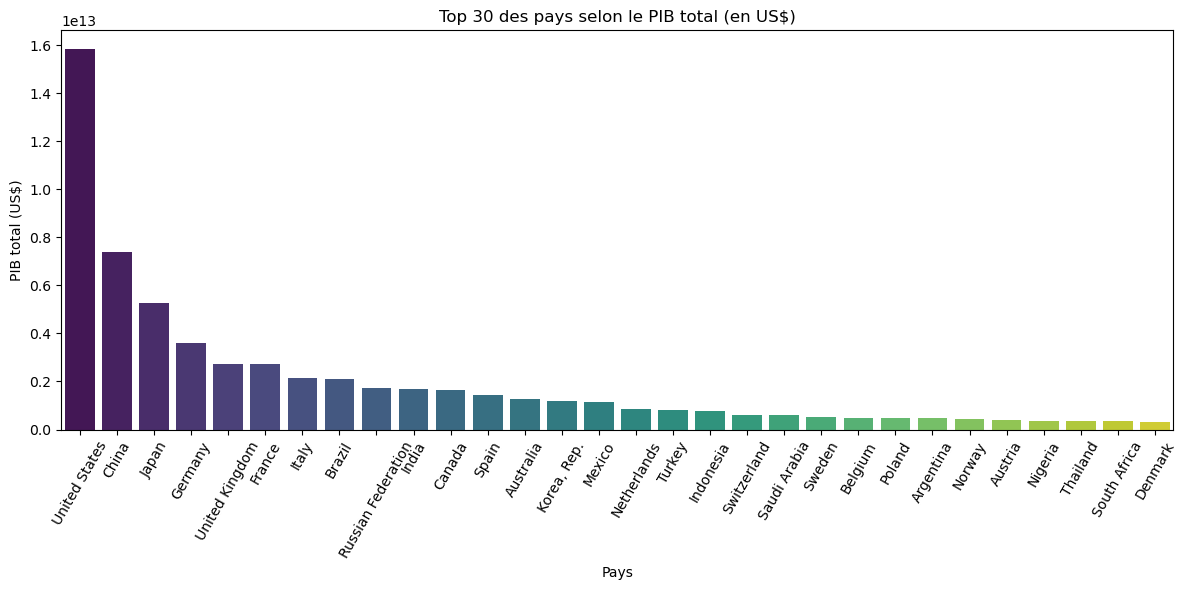

In [87]:

# Sélection des 10 pays avec le PIB total le plus élevé
top10_pib = df_C.sort_values(by='GDP at market prices (current US$)', ascending=False).head(30)

# Création du graphique
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Country Name',
    y='GDP at market prices (current US$)',
    data=top10_pib,
    palette='viridis'
)

plt.title('Top 30 des pays selon le PIB total (en US$)')
plt.xlabel('Pays')
plt.ylabel('PIB total (US$)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Le graphique montre les 10 pays ayant le PIB total (en US$) le plus élevé. On observe que les États-Unis dominent largement, suivis par la Chine et le Japon. Les pays européens comme l’Allemagne, le Royaume-Uni, la France et l’Italie sont également bien représentés, tout comme les grandes économies émergentes telles que le Brésil, la Russie et l’Inde. Cela reflète la hiérarchie économique mondiale classique.

# Analysez des données de systèmes éducatifs PARTIE 3

## Identifier les indicateurs redondants

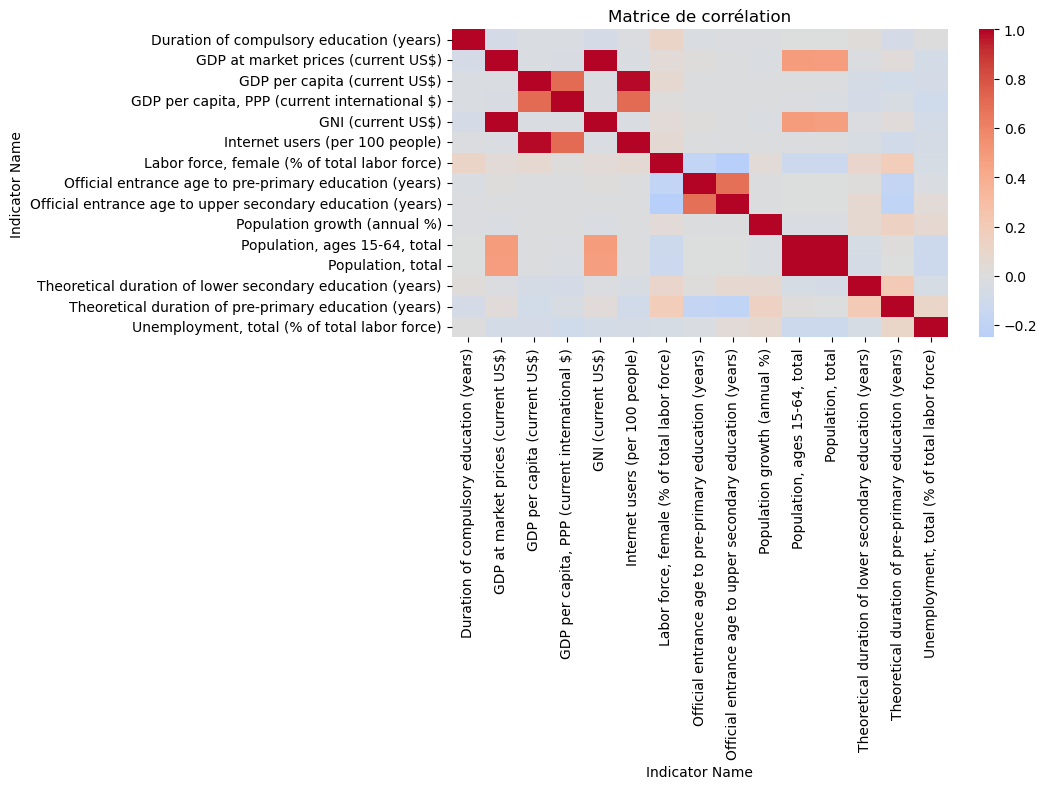

In [88]:
corr = df_C.corr(numeric_only=True)
plt.figure(figsize=(8,4))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()


Avec la matrice de corrélation, on remarque que certaines variables sont très fortement corrélées entre elles. Cela signifie qu’elles transmettent quasiment la même information, donc il n’est pas utile de toutes les garder.

Par exemple, les variables suivantes sont très proches :

GDP at market prices (current US$)

GDP per capita (current US$)

GDP per capita, PPP (current international $)

GNI (current US$)

Population, total

Population ages 15–64 (% of total)

Official entrance age to pre-primary

Official entrance age to upper secondary

Ces variables étant redondantes, on peut en garder seulement une ou deux parmi elles, en fonction de leur pertinence pour notre problématique.

Nous allons donc procéder à la suppression des variables suivantes, car elles sont moins pertinentes que les autres dans notre analyse :

GDP per capita (current US$)

Internet users (per 100 people)

Population growth (annual %)

Duration of compulsory education (years)

Unemployment, total (% of total labor force)

Pour mieux comprendre les liens entre les indicateurs, j’ai utilisé une matrice de corrélation avec la méthode corr() de Pandas et la fonction heatmap() de Seaborn. Cela permet de repérer les indicateurs qui se ressemblent trop, c’est-à-dire ceux qui évoluent presque toujours ensemble. Quand deux indicateurs sont trop corrélés (plus de 70 %), je garde uniquement celui qui est le plus utile pour répondre à ma problématique. Il faut savoir que la corrélation ne veut pas dire qu’un indicateur influence l’autre, et qu’elle ne montre pas les relations trop complexes ou avec des valeurs extrêmes. Enfin, pour avoir une vue plus détaillée, on peut aussi utiliser la fonction pairplot() de Seaborn.

In [89]:
indicateurs_a_supprimer = [
    "GDP per capita (current US$)",
    "GDP per capita, PPP (current international $)",
    "GNI (current US$)",
    "Population, ages 15-64, total",
]
df_C = df_C.drop(columns=indicateurs_a_supprimer)

In [90]:
df_C.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Country Name                                                143 non-null    object 
 1   Duration of compulsory education (years)                    143 non-null    float64
 2   GDP at market prices (current US$)                          143 non-null    float64
 3   Internet users (per 100 people)                             143 non-null    float64
 4   Labor force, female (% of total labor force)                143 non-null    float64
 5   Official entrance age to pre-primary education (years)      143 non-null    float64
 6   Official entrance age to upper secondary education (years)  143 non-null    float64
 7   Population growth (annual %)                                143 non-null    float64
 8   

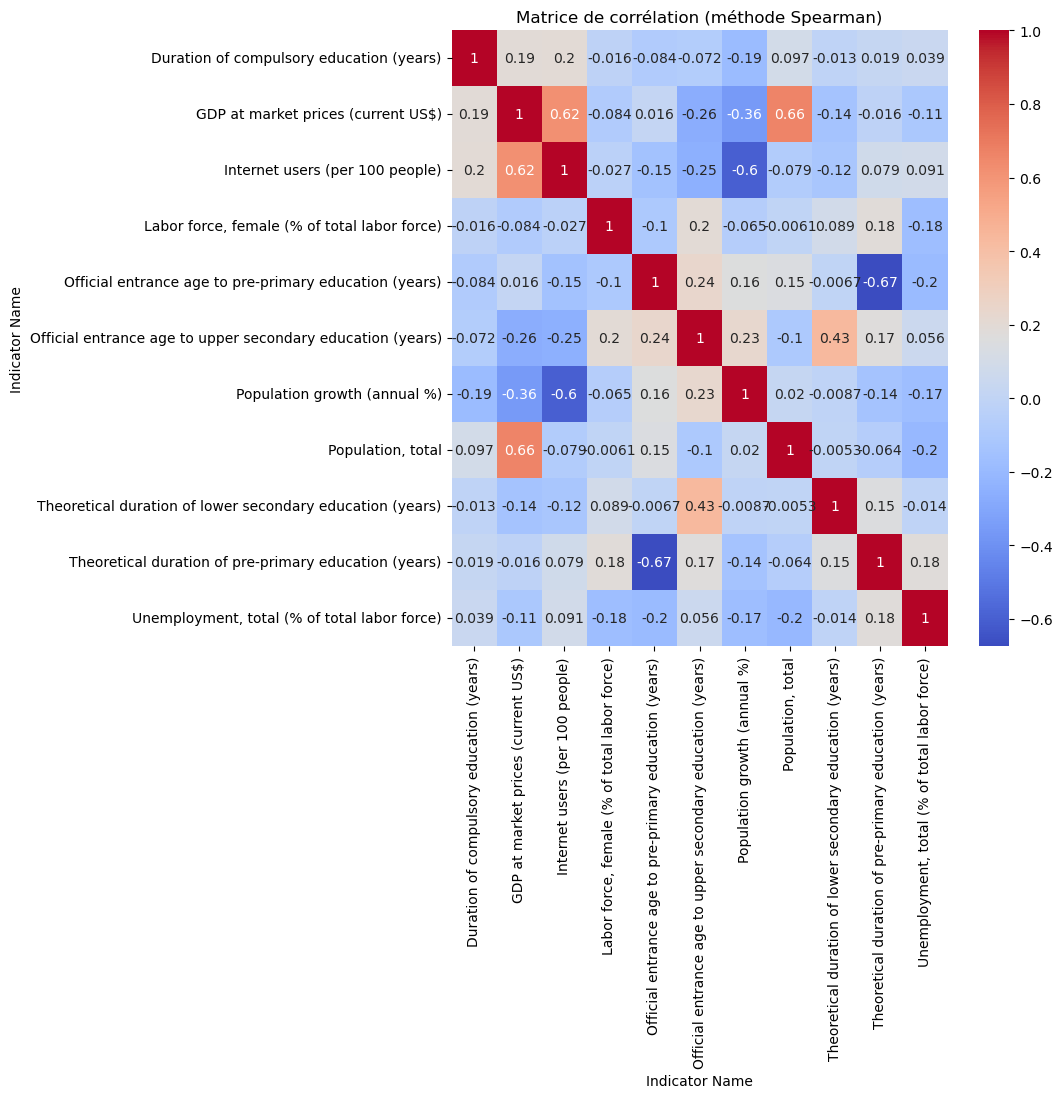

In [91]:
# On enlève la colonne non numérique
correlation_spearman = df_C.drop(columns=["Country Name"]).corr(method='spearman')

plt.figure(figsize=(8, 8))
sns.heatmap(correlation_spearman, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation (méthode Spearman)")
plt.show()



Sur cette matrice de corrélation Spearman, on observe que :

La plupart des variables sont faiblement corrélées entre elles, ce qui est une bonne chose pour l’analyse : elles apportent des informations différentes.

Certaines paires présentent tout de même des corrélations modérées, comme :

GDP at market prices (current US$) et Population, total (corrélation ≈ 0.68)

Internet users et GDP (corrélation ≈ 0.56)

Mais aucune variable ne dépasse le seuil de 0.7 en valeur absolue, donc aucune suppression n’est strictement nécessaire ici d’après ce critère.

## Analyser les indicateurs restants & sélectionner les pays

In [92]:
df_C.head(10)

Indicator Name,Country Name,Duration of compulsory education (years),GDP at market prices (current US$),Internet users (per 100 people),"Labor force, female (% of total labor force)",Official entrance age to pre-primary education (years),Official entrance age to upper secondary education (years),Population growth (annual %),"Population, total",Theoretical duration of lower secondary education (years),Theoretical duration of pre-primary education (years),"Unemployment, total (% of total labor force)"
0,Albania,8.44,1.223377e+10,45.48,42.05,3.000000e+00,1.478000e+01,-0.42,2.914263e+06,4.0,3.0,14.68
1,Algeria,10.00,1.781015e+11,18.52,17.58,7.488309e+09,7.488309e+09,1.84,3.693922e+07,4.0,1.0,10.88
2,Angola,6.00,9.741730e+10,5.53,49.99,5.000000e+00,1.500000e+01,3.54,2.430762e+07,3.0,1.0,6.26
3,Argentina,13.11,4.605438e+11,48.06,40.91,3.000000e+00,1.500000e+01,1.03,4.167430e+07,3.0,3.0,7.62
4,Australia,10.00,1.253340e+12,77.99,45.34,4.000000e+00,1.600000e+01,1.55,2.235955e+07,4.0,1.0,5.29
5,Austria,9.00,4.117352e+11,77.24,46.24,3.000000e+00,1.400000e+01,0.48,8.422163e+06,4.0,3.0,5.02
6,Azerbaijan,9.33,5.746844e+10,48.25,49.49,3.000000e+00,1.500000e+01,1.43,9.157374e+06,5.0,3.0,5.44
7,"Bahamas, The",12.00,9.296388e+09,55.45,47.79,3.000000e+00,1.400000e+01,1.57,3.657273e+05,3.0,2.0,12.79
8,Bangladesh,5.00,1.298831e+11,6.17,26.59,3.000000e+00,1.400000e+01,1.15,1.540406e+08,3.0,3.0,4.24
9,Barbados,11.00,4.572111e+09,67.80,49.32,3.000000e+00,1.400000e+01,0.36,2.804228e+05,3.0,2.0,10.47


In [93]:
df_C["Internet users (per 100 people)"].describe()


count    1.430000e+02
mean     1.618497e+08
std      1.935441e+09
min      1.280000e+00
25%      1.157000e+01
50%      3.509000e+01
75%      6.015000e+01
max      2.314451e+10
Name: Internet users (per 100 people), dtype: float64

In [94]:
df_C = df_C[df_C["Internet users (per 100 people)"] < 100]


/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/4046331961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


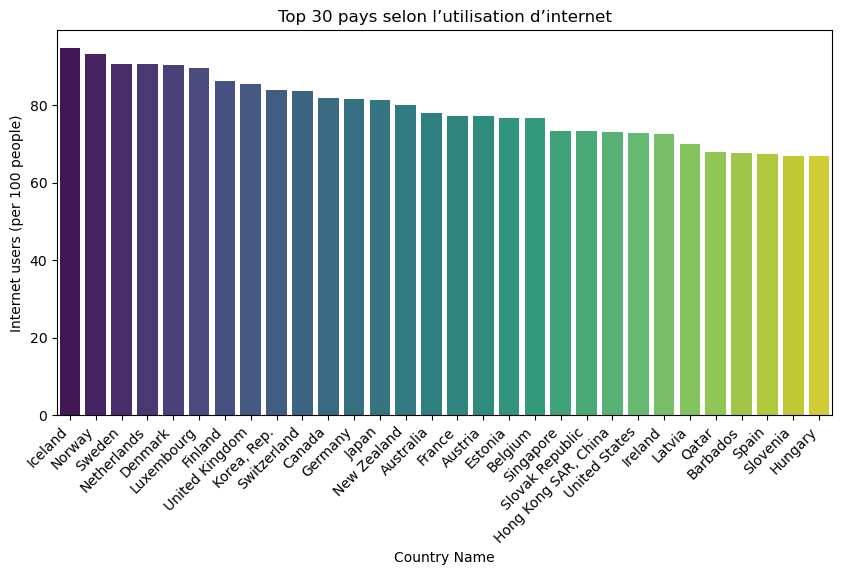

In [95]:
top20 = df_C.sort_values("Internet users (per 100 people)", ascending=False).head(30)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top20,
    x="Country Name",
    y="Internet users (per 100 people)",
    palette="viridis"
)
plt.xticks(rotation=45, ha='right')
plt.title("Top 30 pays selon l’utilisation d’internet")
plt.show()


Le graphique présente les pays ayant le plus haut taux d’utilisateurs d’Internet (pour 100 habitants).
On observe que :

Les pays nordiques (Islande, Norvège, Suède, Danemark) dominent le classement avec des taux supérieurs à 90 %.

Les pays européens sont majoritairement représentés, traduisant une forte connectivité du continent.

Quelques pays hors Europe (Japon, Canada, Australie, Singapour) se distinguent également par une adoption élevée du numérique.

In [96]:

def descri_graph(df_C, col, top_n=30):
    if col not in df_C.columns:
        print(f"La colonne '{col}' n'existe pas dans le DataFrame.")
        return
    
    df_C = df_C[df_C[col] < 100]
    print(df_C[col].describe(), "\n")
    
    top_pays = df_C.sort_values(by=col, ascending=False).head(top_n)
    
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=top_pays,
        x="Country Name",
        y=col,
        palette="viridis"
    )
    plt.title(f"Top {top_n} pays selon {col}")
    plt.xlabel("Country Name")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

        

count    132.000000
mean       9.435152
std        1.965376
min        5.000000
25%        9.000000
50%        9.055000
75%       10.670000
max       14.000000
Name: Duration of compulsory education (years), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


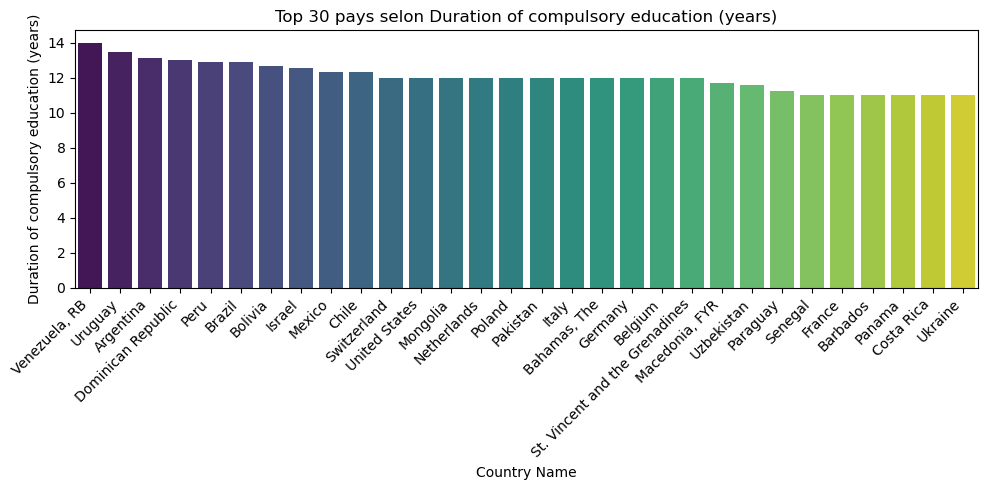

In [97]:
descri_graph(df_C,"Duration of compulsory education (years)")

count    142.000000
mean      42.067394
std        8.262133
min       11.400000
25%       39.532500
50%       44.550000
75%       47.482500
max       54.670000
Name: Labor force, female (% of total labor force), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


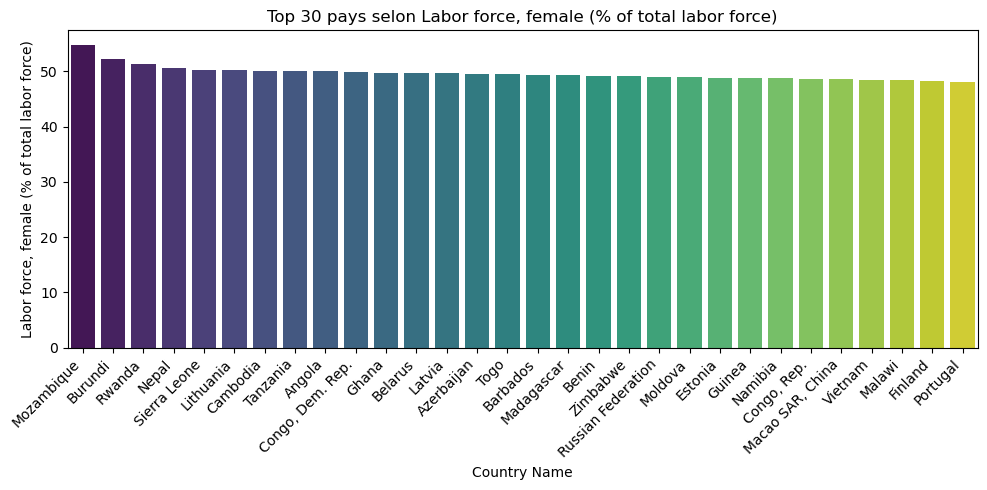

In [98]:
descri_graph(df_C, "Labor force, female (% of total labor force)")

count    140.000000
mean       3.358643
std        0.603033
min        3.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.780000
Name: Official entrance age to pre-primary education (years), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


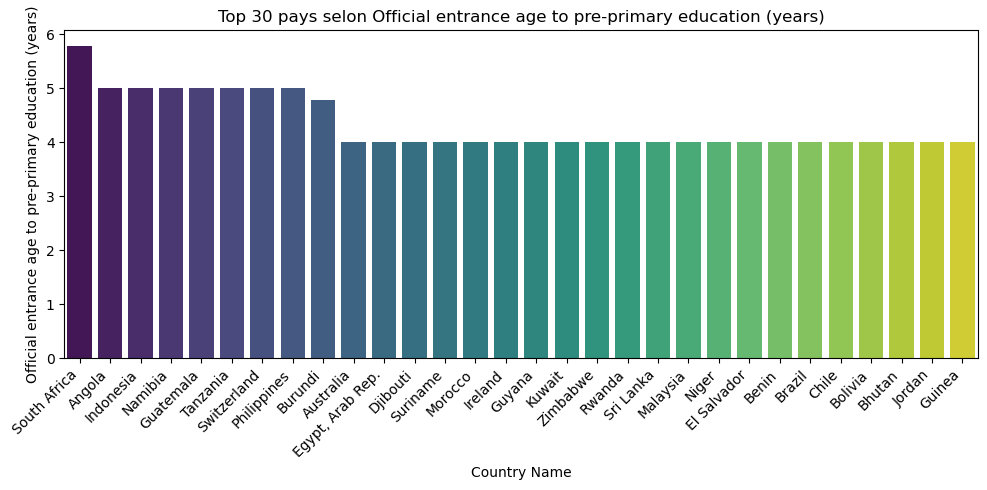

In [99]:
descri_graph(df_C, "Official entrance age to pre-primary education (years)")

count    141.000000
mean      15.277305
std        0.853666
min       13.000000
25%       15.000000
50%       15.000000
75%       16.000000
max       18.000000
Name: Official entrance age to upper secondary education (years), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


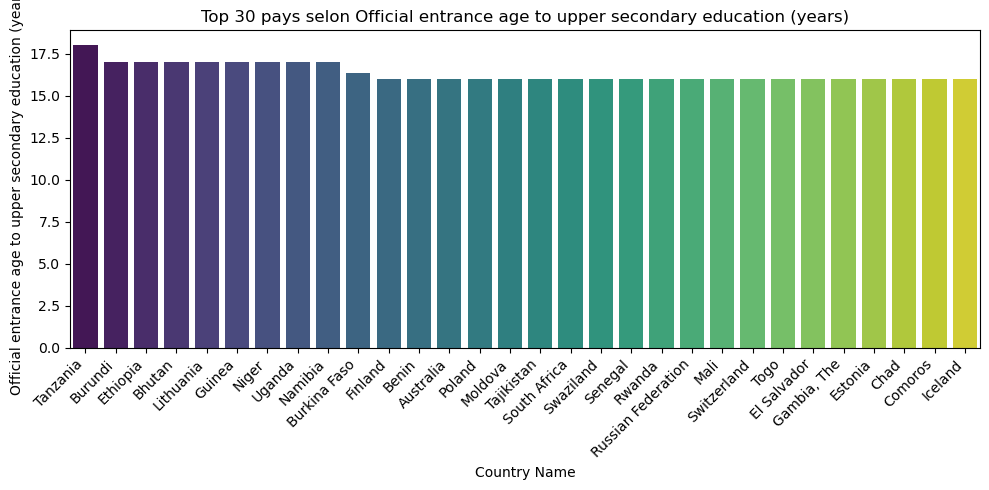

In [100]:
descri_graph(df_C,"Official entrance age to upper secondary education (years)")

count    141.000000
mean       1.536312
std        1.414246
min       -1.320000
25%        0.500000
50%        1.430000
75%        2.370000
max        9.980000
Name: Population growth (annual %), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


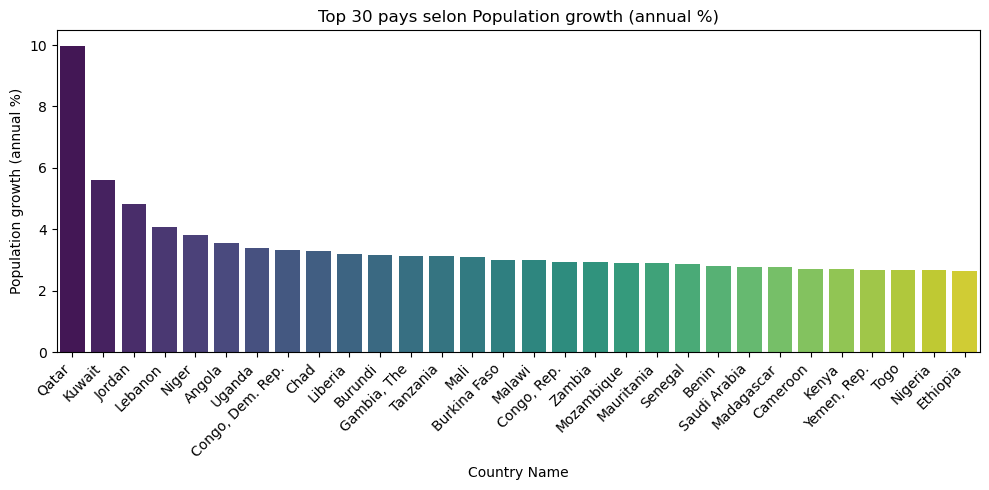

In [101]:
descri_graph(df_C, "Population growth (annual %)")

count    142.000000
mean       3.380986
std        0.788097
min        2.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: Theoretical duration of lower secondary education (years), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


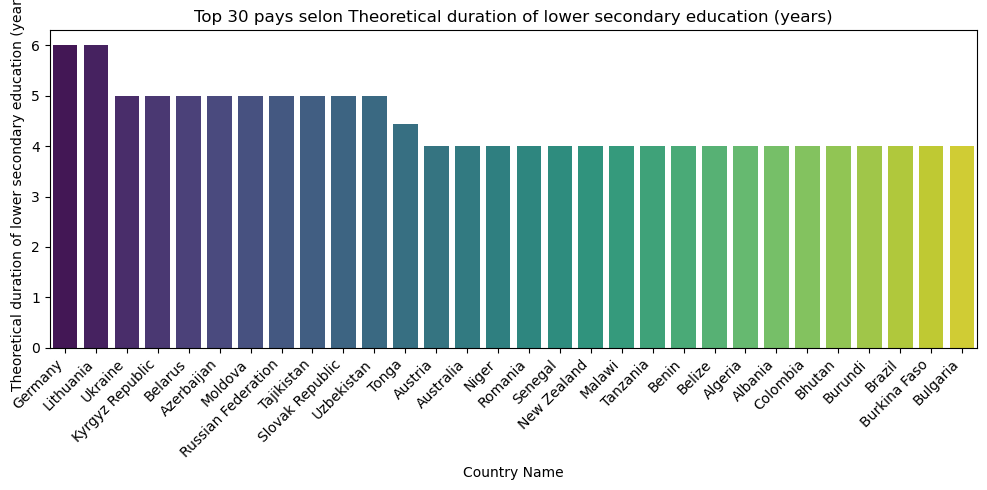

In [102]:
descri_graph(df_C, "Theoretical duration of lower secondary education (years)")

count    142.000000
mean       2.754155
std        0.733411
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: Theoretical duration of pre-primary education (years), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


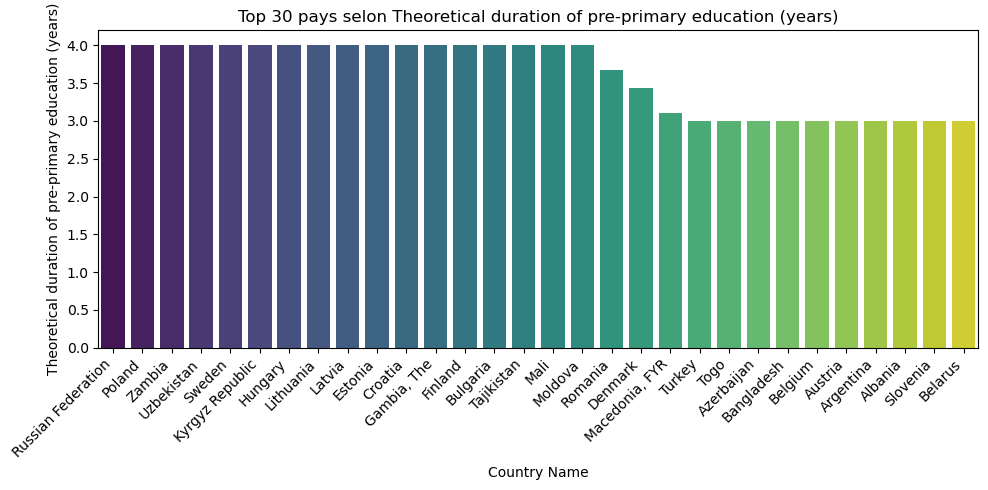

In [103]:
descri_graph(df_C, "Theoretical duration of pre-primary education (years)")

count    142.000000
mean       8.321338
std        6.058088
min        0.310000
25%        4.440000
50%        6.770000
75%       10.035000
max       31.080000
Name: Unemployment, total (% of total labor force), dtype: float64 



/var/folders/dl/grllz11s10j3k3rm1rt8w0nw0000gn/T/ipykernel_7455/2596627640.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


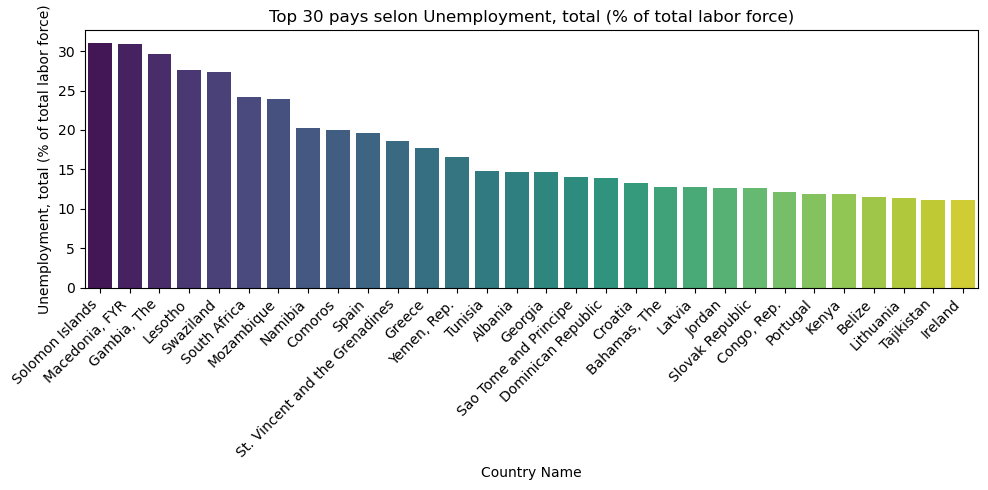

In [104]:
descri_graph(df_C, "Unemployment, total (% of total labor force)")

In [105]:

# Liste structurée des pays sélectionnés
pays_selection = [
    # Europe
    {"Pays": "Allemagne", "Région": "Europe", "Raisons": "PIB élevé, éducation solide, haut accès Internet"},
    {"Pays": "Finlande", "Région": "Europe", "Raisons": "Excellence éducative, haut niveau numérique"},
    {"Pays": "Suède", "Région": "Europe", "Raisons": "Connectivité forte, stabilité sociale"},
    {"Pays": "Danemark", "Région": "Europe", "Raisons": "Égalité, digitalisation, éducation performante"},
    {"Pays": "France", "Région": "Europe", "Raisons": "Grand marché, infrastructure éducative développée"},
    {"Pays": "Suisse", "Région": "Europe", "Raisons": "Qualité éducative, haut niveau de vie"},
    {"Pays": "Pays-Bas", "Région": "Europe", "Raisons": "Très digitalisé, bon système éducatif"},
    {"Pays": "Japon", "Région": "Asie", "Raisons": "Avancée technologique, haut niveau d’éducation"},
    {"Pays": "Chine", "Région": "Asie", "Raisons": "Marché massif, développement numérique rapide"},
    {"Pays": "Inde", "Région": "Asie", "Raisons": "Population jeune, croissance EdTech forte"},
    {"Pays": "Éthiopie", "Région": "Afrique", "Raisons": "Croissance démographique et éducative"},
    {"Pays": "Mozambique", "Région": "Afrique", "Raisons": "Participation féminine élevée, marché émergent"},
    {"Pays": "Nigeria", "Région": "Afrique", "Raisons": "Économie forte, connectivité numérique croissante"},
    {"Pays": "Brésil", "Région": "Amérique", "Raisons": "Grand marché éducatif, adoption numérique"},
    {"Pays": "Argentine", "Région": "Amérique", "Raisons": "Éducation longue, croissance technologique"}
]

# Création du DataFrame
df_selection_pays = pd.DataFrame(pays_selection)

df_selection_pays


,Pays,Région,Raisons
0,Allemagne,Europe,"PIB élevé, éducation solide, haut accès Internet"
1,Finlande,Europe,"Excellence éducative, haut niveau numérique"
2,Suède,Europe,"Connectivité forte, stabilité sociale"
3,Danemark,Europe,"Égalité, digitalisation, éducation performante"
4,France,Europe,"Grand marché, infrastructure éducative développée"
5,Suisse,Europe,"Qualité éducative, haut niveau de vie"
6,Pays-Bas,Europe,"Très digitalisé, bon système éducatif"
7,Japon,Asie,"Avancée technologique, haut niveau d’éducation"
8,Chine,Asie,"Marché massif, développement numérique rapide"
9,Inde,Asie,"Population jeune, croissance EdTech forte"


J’ai sélectionné ces pays car ce sont ceux qui apparaissent le plus fréquemment dans les différents graphiques analysés. Ils présentent des performances élevées sur la majorité des indicateurs clés, notamment en matière d’éducation, de connectivité numérique, de participation économique et de stabilité démographique. Ces résultats suggèrent que ces pays constituent les marchés les plus favorables à une future implantation internationale.